In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import json
import os
import numpy as np
from PIL import Image

class EpisodeDataset(Dataset):
    def __init__(self, json_file, image_dir, transform=None):
        with open(json_file) as f:
            self.data = json.load(f)

        self.image_dir = image_dir
        self.transform = transform

        # Map episode names -> label index
        self.episodes = list(self.data.keys())
        self.label_map = {ep: i for i, ep in enumerate(self.episodes)}

        # Flatten into (image_path, label)
        self.samples = []
        for ep in self.episodes:
            for img_name in self.data[ep]:
                path = os.path.join(image_dir, img_name)
                self.samples.append((path, self.label_map[ep]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        img = Image.open(path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.long)
            

In [21]:
from torch.utils.data import Subset
import random

def episode_wise_split(dataset, train_ratio=0.8):
    train_indices = []
    test_indices = []

    # Group indices by label (episode)
    label_to_indices = {}

    for idx, (_, label) in enumerate(dataset.samples):
        label_to_indices.setdefault(label, []).append(idx)

    # Split each episode separately
    for label, indices in label_to_indices.items():
        random.shuffle(indices)

        split = int(len(indices) * train_ratio)
        train_idx = indices[:split]
        test_idx = indices[split:]

        train_indices.extend(train_idx)
        test_indices.extend(test_idx)

    return Subset(dataset, train_indices), Subset(dataset, test_indices)

In [22]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])



In [23]:
dataset = EpisodeDataset("episodes.json", "randomframes", transform=train_transform)

train_dataset, test_dataset = episode_wise_split(dataset, 0.8)
test_dataset.dataset.transform = test_transform

from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [24]:
import torch.nn as nn
from torchvision import models

model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.last_channel, 61)

for param in model.parameters():
    param.requires_grad = False

# Unfreeze final layer
for param in model.classifier.parameters():
    param.requires_grad = True

In [25]:
import torch.optim as optim
import time  # <-- add this

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = model.to(device)

import matplotlib.pyplot as plt

cpu


In [26]:


train_losses = []
test_losses = []

best_test_loss = float("inf")
patience = 3
epochs_no_improve = 0

num_epochs = 1  # you can keep this high; time will limit training

max_time = 2*60* 60 
start_time = time.time()

for epoch in range(num_epochs):
    # ---- TIME CHECK ----
    elapsed_time = time.time() - start_time
    if elapsed_time > max_time:
        print(f"Stopping: reached {max_time//60} minute time limit.")
        break

    # ---- TRAIN ----
    model.train()
    running_train_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ---- VALIDATION ----
    model.eval()
    running_test_loss = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_test_loss += loss.item()

    avg_test_loss = running_test_loss / len(test_loader)
    test_losses.append(avg_test_loss)

    print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Test Loss={avg_test_loss:.4f}")

    # ---- EARLY STOPPING ----
    if avg_test_loss < best_test_loss:
        best_test_loss = avg_test_loss
        epochs_no_improve = 0

        # Save best model
        torch.save(model.state_dict(), "best_model.pth")

    else:
        epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print("Early stopping triggered!")
            break

Epoch 1: Train Loss=3.7658, Test Loss=3.3788


In [27]:
model.load_state_dict(torch.load("best_model.pth", map_location=device)) #test acc 51%
model = model.to(device)
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print(f"Test Accuracy: {accuracy:.4f}")


Test Accuracy: 0.2320


In [28]:

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        if total>300:
            break

print("Train Accuracy:", correct / total)

Train Accuracy: 0.359375


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
torch.save(model.state_dict(), "res_model.pth")
model.eval()

# Get label → episode name mapping (reverse of label_map)
idx_to_episode = {v: k for k, v in dataset.label_map.items()}

# Collect all test samples
images_list = []
labels_list = []
preds_list = []
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        images_list.append(images.cpu())
        labels_list.append(labels.cpu())
        preds_list.append(predicted.cpu())



# Concatenate
images_all = torch.cat(images_list)
labels_all = torch.cat(labels_list)
preds_all = torch.cat(preds_list)




Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.2385478].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5702832].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6051416].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2391288].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.535425].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.803

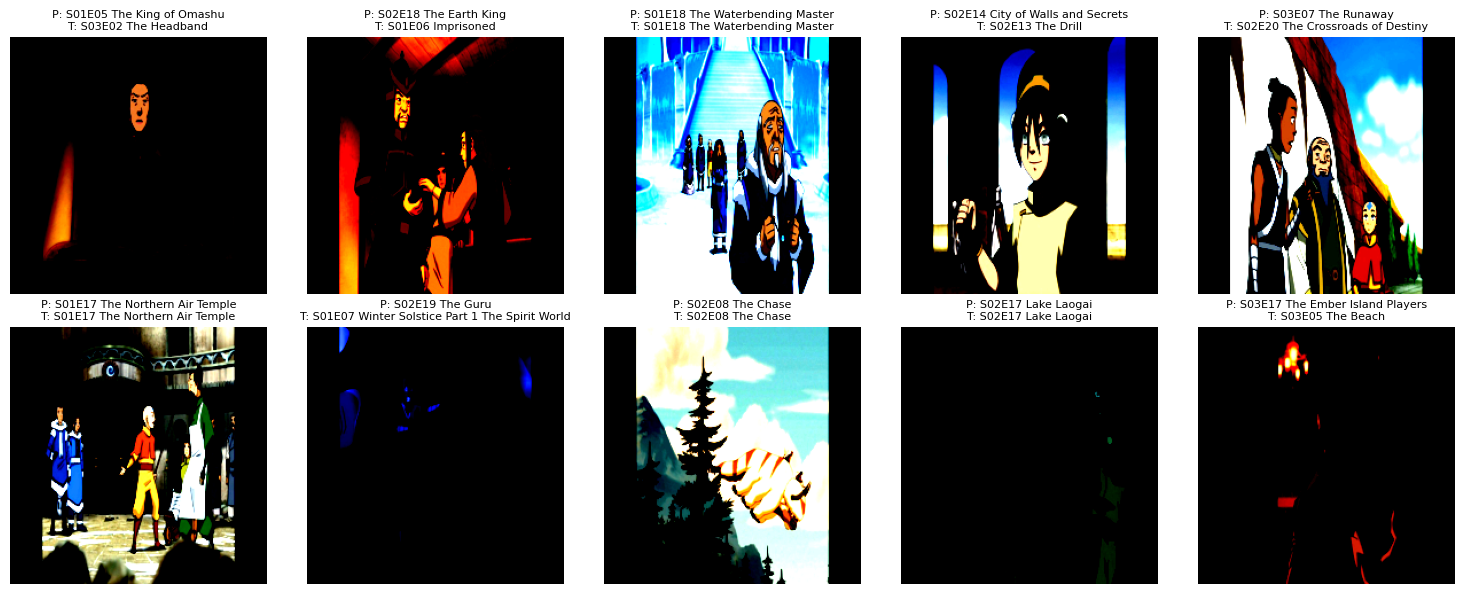

In [30]:

# Pick 10 random indices
indices = np.random.choice(len(images_all), 10, replace=False)

# Plot
plt.figure(figsize=(15, 6))

for i, idx in enumerate(indices):
    img = images_all[idx]

    # Convert CHW → HWC
    img = img.permute(1, 2, 0).numpy()

    true_label = idx_to_episode[labels_all[idx].item()]
    pred_label = idx_to_episode[preds_all[idx].item()]

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"P: {pred_label}\nT: {true_label}", fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [31]:
from PIL import Image
import torch

# Make sure model is loaded
model.load_state_dict(torch.load("res_model.pth", map_location=device))
model = model.to(device)
model.eval()

# Use SAME transform as test data
transform = test_transform

# Load your image
img_path = "test.jpg"
img = Image.open(img_path).convert("RGB")

# Apply transform
img = transform(img)

# Add batch dimension (1, C, H, W)
img = img.unsqueeze(0).to(device)

# Inference
with torch.no_grad():
    outputs = model(img)
    print(outputs)
    _, predicted = torch.max(outputs, 1)

# Convert label index → episode name
pred_label = predicted.item()
pred_episode = idx_to_episode[pred_label]

print("Predicted episode:", pred_episode)

tensor([[-2.1818, -2.4783, -1.9242, -3.6425, -2.6773, -3.0665, -1.6003, -0.8320,
         -2.8884, -1.7959, -2.3281, -2.3057, -2.9244, -2.0269, -3.2377, -1.2511,
         -2.6794, -1.3392, -1.9586, -1.4922, -2.4847, -2.3979, -2.5541, -2.1325,
         -2.9759, -2.9834, -1.5720, -1.9573, -2.1894, -2.0376, -2.0127, -3.8825,
         -1.4195, -3.2811, -2.5523, -2.9035, -3.0354, -3.1200, -1.0169, -0.5381,
         -1.8498, -2.6665, -1.7817, -2.7817, -2.2660, -1.0089, -2.1939, -2.2599,
         -1.8993, -2.6599, -2.2992, -3.6326, -1.9646, -3.2625, -3.7567, -2.7158,
         -3.3313, -2.3612, -3.4778, -0.4435, -0.2536]])
Predicted episode: S03E21 Sozins Comet Part 4 Avatar Aang
